# rENM Framework User Manual

Version 0.1.0

John L. Schnase  
2026-06-21



> **Caution**
>
> ***Content is subject to ongoing revision and periodic updates …***

# Introduction

The rENM Framework is a modular suite of R packages designed to support
the development and analysis of retrospective ecological niche models
(rENMs). Retrospective ecological niche modeling integrates historical
species occurrence records with historical environmental data to
reconstruct the spatio-temporal dynamics of species’ responses to
changing environmental conditions.

By revealing long-term patterns, rENMs provide an empirical basis for
addressing biological questions and assessing both the current and
future conservation status of species. Rather than treating ecological
niche models as static representations, the rENM Framework uses
time-structured modeling to reveal:

- Long-term trends in climatic suitability for a species
- Acceleration and deceleration of those trends
- Directional change in suitability and shifts in the
  suitability-weighted geographic center of a species’ climatic niche
- Changes in the relative importance of environmental predictors across
  decades
- Bioclimatic velocity
- Hotspots of accelerating suitability decline

Although this analytical approach is broadly applicable across taxa, the
current implementation of the rENM Framework is designed to investigate
climate-driven dynamics in North American bird species. The framework
spans 45 years (1980–2024), leveraging citizen science observations from
the Cornell Lab of Ornithology’s eBird database alongside environmental
data derived from NASA’s Modern-Era Retrospective Analysis for Research
and Applications, Version 2 (MERRA-2).

This manual guides users through the rENM modeling and analysis
workflow. Detailed documentation for individual functions is available
within the respective package manuals. Additional information about this
work can be found in the Appendix A publications and the project’s
GitHub repository at: <https://github.com/rENM-Framework>.

The rENM Framework is an active research platform under ongoing
development. It is provided for educational and research purposes only
and is distributed without formal technical support. Feedback and
contributions are welcome.

Thank you for your interest.

John Schnase  
rENM.Framework@gmail.com



# The rENM Workflow

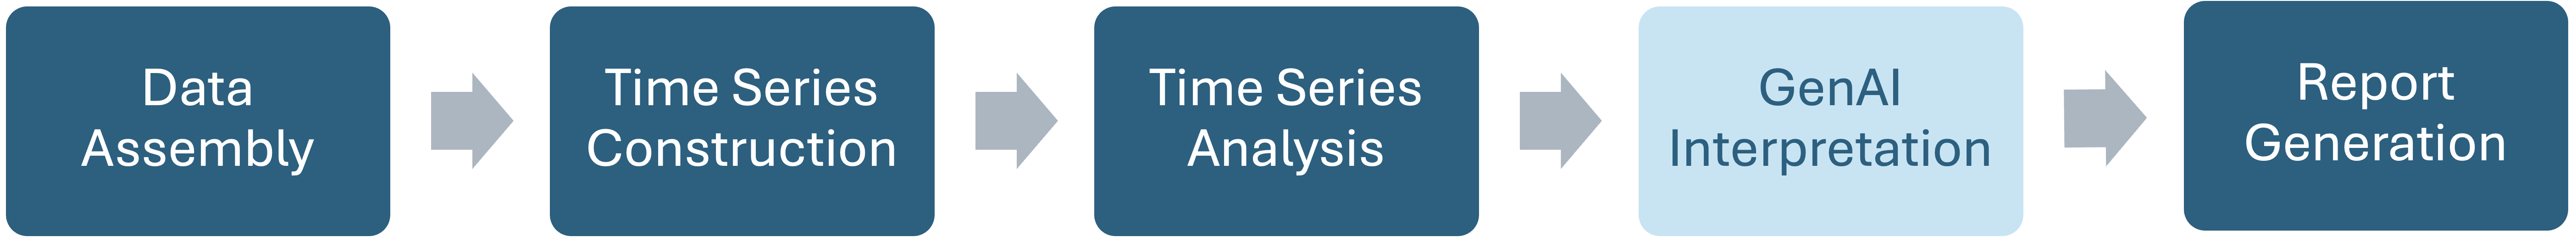

The rENM processing pipeline consists of five core steps, including an
optional, experimental GenAI-mediated interpretation step. One way to
engage this workflow is by using this Quarto Markdown (.qmd) document as
an interactive user manual. It becomes a reproducible, executable
scientific document that combines code, results, and narrative into a
single, renderable file.

## Using the Quarto document

After initially configuring your host environment and RStudio
environment (see *Configuring the Host Environment* and *Configuring the
RStudio Environment* below), set the species banding code and step
through each section in sequence, reading the narrative description of
each processing step and executing the accompanying code block before
moving on. This mode is well suited to users who are learning the
framework.

You may also copy the *rENM-Framework-User-Manual.qmd* file, rename it,
and use it as a customized, reproducible analysis notebook for your own
species or study system. Because the document combines function calls,
parameter settings, and narrative in a single file, it can serve
alongside a run’s output directory as a complete and portable record of
the analysis.

Finally, from the RStudio **`Run`** drop-down menu, select *Restart R
and Run All Chunks* to execute the entire workflow automatically,
without stepping through it manually.

## Automated scripting

If you prefer not to run an rENM analysis step by step, you can execute
the full pipeline from the RStudio console with a single function call.
For example: `rENM("CASP")`. Enter `?rENM` in the RStudio console for
details.

## Document rendering options

If you use the *rENM-Framework-User-Manual.qmd* file as a template for
your own species or study system, RStudio’s Quarto rendering engine can
convert it to multiple output formats from the `Render` drop-down menu,
including HTML, PDF, and Microsoft Word (DOCX). A Jupyter Notebook
(IPYNB) version can also be rendered, producing a notebook that executes
the same rENM Framework functions in an R kernel environment and making
the workflow accessible to users who prefer the Jupyter interface
without requiring any modification to the underlying R code.

# System Requirements

The rENM Framework requires R (≥ 4.1.0) and two external software
dependencies, LibreOffice and Chrome or Chromium, that must be installed
separately before the full pipeline can run. The Framework has been
developed and tested on macOS and is expected to be compatible with
Linux. Windows users may experience longer run times due to limited
support for parallel processing on that platform. All R package
dependencies are installed automatically when you install the framework
packages from GitHub (see *Installing the Framework Packages* below).

## R package dependencies

Two framework packages pull in heavy R dependencies worth anticipating
before installation:

- **`rENM.model`** depends on `sdm`, which requires `randomForest`,
  `gbm`, and `earth` as modeling back-ends. These are installed on first
  use.
- **`rENM.analysis`** depends on `rstanarm` for Bayesian trend
  estimation. `rstanarm` is large and may take several minutes to
  compile on first install.

The `rENM.reports` package uses `webshot2`, `pagedown`, and `chromote`
for PNG and PDF rendering of summary tables. These are optional and must
be installed separately (see *Chrome or Chromium* below). The Excel
(XLSX) output from summary table functions is always written regardless
of whether these packages are installed.

## LibreOffice

`rENM.ai::render_ai_docx()` converts AI-generated DOCX reports to PDF
using LibreOffice in headless mode. LibreOffice must be installed before
using that function.

Download from <https://www.libreoffice.org>. On macOS, LibreOffice
installs to `/Applications` but its `soffice` binary is not added to
`PATH` automatically. Run this once in Terminal after installing:

``` bash
sudo ln -s /Applications/LibreOffice.app/Contents/MacOS/soffice /usr/local/bin/soffice
```

On Linux, install via your package manager (e.g.,
`apt install libreoffice`); `soffice` is placed on `PATH` automatically.
If LibreOffice is absent when `render_ai_docx()` is called, a clear
error message is displayed with installation instructions.

## Chrome or Chromium

`rENM.reports` renders summary tables as PNG and PDF files by driving a
headless Chrome browser via the `chromote`, `webshot2`, and `pagedown`
packages. Install these R packages first:

``` r
install.packages(c("chromote", "webshot2", "pagedown"))
```

Then verify Chrome is found before running the pipeline:

``` r
chromote::find_chrome()
```

If that call throws an error, install Google Chrome from
<https://www.google.com/chrome/> and re-run `chromote::find_chrome()` to
confirm. If Chrome is unavailable at runtime, PNG and PDF outputs from
the summary table functions are silently skipped with a console note;
the XLSX output is always written regardless.

## Troubleshooting package installation

The rENM Framework uses `paletteer` for color scales in several plotting
functions. If you encounter an unexpected “package not found” error
during a plotting step, check whether a `paletteer`-based color scale is
the source. The missing package will be named in the error message;
install it with `install.packages()` and re-run the function.

# Configuring the Host Environment

The rENM Framework relies on a simple, standardized filesystem
structure. At the top level is a project directory containing a `data`
subdirectory for input datasets and a `runs` subdirectory where model
outputs and analysis results are written. The initial setup creates this
structure, installs the example dataset, and creates a symbolic link
that points to it from the `data` subdirectory.

    PROJECT_DIRECTORY/
    |___ data -> (symbolic link to dataset in use)
    |___ rENM-Framework-v0.1.0-example-data/...
    |___ rENM-Framework-v0.1.0-extended-data/...
    |___ my_input_data/...
    |___ runs/...

You only need to configure your host environment once. The examples
below assume a macOS or Linux environment using the Bash shell. If you
prefer to run these commands outside of RStudio, equivalent scripts are
available at <https://github.com/rENM-Framework/rENM-scripts>.

## Creating the project directory

Create the project directory and the `runs` subdirectory from a terminal
window. The name `rENMtest` is used here for illustration; choose a name
that fits your own workflow.

``` bash
#!/usr/bin/env bash

# set project directory name
PROJECT_DIRECTORY="$HOME/rENMtest"

# create initial directory structure
mkdir -p "$PROJECT_DIRECTORY"
mkdir -p "$PROJECT_DIRECTORY/runs"
```

## Installing the example dataset

The example dataset includes occurrence records for three focal species:
Brown-capped Rosy-Finch (*Leucosticte australis*; BCRF), Cassin’s
Sparrow (*Peucaea cassinii*; CASP), and Greater Roadrunner (*Geococcyx
californianus*; GRRO). Also included are 14 MERRA-2 and MERRAclim-2
environmental variables, shapefiles for state boundaries and species
ranges, and a catalog of the dataset’s contents. The dataset is
approximately 725 MB.

The dataset is archived on Zenodo and downloaded automatically by the
commands below. Make sure your current working directory is the project
directory you created above, then run the following commands from a
terminal window to download and install it:

``` bash
#!/usr/bin/env bash

# set project directory name (same as above)
PROJECT_DIRECTORY="$HOME/rENMtest"
cd "${PROJECT_DIRECTORY}"

# download and unzip example dataset
DATA_URL="https://zenodo.org/records/20750253/files/rENM-Framework-v0.1.0-example-data.zip"
ZIP_FILE="rENM-Framework-v0.1.0-example-data.zip"
curl -L -o "${ZIP_FILE}" "${DATA_URL}"
unzip -o "${ZIP_FILE}"

# create symbolic link
ln -sfn rENM-Framework-v0.1.0-example-data data

# clean up
rm -rf __MACOSX
rm -f "${ZIP_FILE}"
```

# Configuring the RStudio Environment

All subsequent work is performed in RStudio using R. Begin by specifying
the location of the project directory you created in the previous
section. This allows both RStudio and the rENM Framework to locate and
manage project files consistently across sessions.

## Setting the project directory location

The following command writes the project directory path to your
`.Renviron` file, making it available in every future R session. Run it
once during initial setup, then leave it commented out.

In [ ]:
# # set the location of the project directory
# write(
#   paste0('RENM_PROJECT_DIR="', file.path(Sys.getenv("HOME"), "rENMtest"), '"'),
#   file = "~/.Renviron",
#   append = TRUE
# )
# # reload (or restart R)
# readRenviron("~/.Renviron")
# Sys.getenv("RENM_PROJECT_DIR")

For single-session use, you can set the project directory with
`options(rENM.project_dir = ...)` instead of configuring `.Renviron`.
See `?rENM_project_dir` for details.

## Installing the framework packages

Install the rENM Framework packages from GitHub. The `remotes` package
handles installation from remote repositories and is all that is needed
for this step. Install the packages in the order shown, with the
top-level `rENM` orchestration package last.

In [ ]:
# # install rENM Framework packages from the GitHub repository
# install.packages("remotes")
# remotes::install_github("rENM-Framework/rENM.core")
# remotes::install_github("rENM-Framework/rENM.data")
# remotes::install_github("rENM-Framework/rENM.model")
# remotes::install_github("rENM-Framework/rENM.analysis")
# remotes::install_github("rENM-Framework/rENM.ai")
# remotes::install_github("rENM-Framework/rENM.reports")
# remotes::install_github("rENM-Framework/rENM")  # install last

This step only needs to be completed once.

## Loading the rENM Framework modules

Now, load the installed rENM Framework packages.

In [ ]:
# load the installed rENM Framework packages
library(rENM)
library(rENM.core)
library(rENM.data)
library(rENM.model)
library(rENM.analysis)
library(rENM.reports)
library(rENM.ai)

# Performing an rENM Analysis

Species within the rENM Framework are identified using a four-character
alpha code, following the same conventions used by the North American
Bird Banding Program. The example dataset includes three species that
cover a range of modeling conditions. The Brown-capped Rosy-Finch
(*Leucosticte australis*; BCRF) occupies a small, high-elevation range
in the southern Rockies and has sparse occurrence records, making it a
useful test case for low-density modeling scenarios. Cassin’s Sparrow
(*Peucaea cassinii*; CASP) is the focal species of the Schnase et
al. study series and provides a well-characterized example with an
extensive retrospective literature to draw on. The Greater Roadrunner
(*Geococcyx californianus*; GRRO) has a broad distribution across the
southwestern United States and presents a high-density occurrence record
scenario. Together these three species let you explore how the rENM
Framework behaves across meaningfully different ecological and data
contexts.

## Viewing installed species data

Use the `show_species()` helper function to display the full list of
species available in your project’s data collection, including each
species’ common name, scientific name, and four-letter alpha code. Run
it before setting the banding code to confirm that your target species
is provisioned and to verify the correct alpha code.

In [ ]:
# show available species
rENM.core::show_species()

## Setting the species banding code

Set the alpha code for the species you want to analyze. The code block
below shows all three example species; the others are commented out.
CASP is set as the default here because it is the focal species of the
Schnase et al. study series and has the most thoroughly characterized
outputs to compare against, making it a good first run for users who are
new to the framework.

In [ ]:
# set four-letter banding code of a bird species
# alpha_code <- "BCRF"
alpha_code <- "CASP"
# alpha_code <- "GRRO"

Once `alpha_code` is set, it is passed automatically to all subsequent
functions in the workflow.

# Data Assembly

Data assembly prepares the two classes of inputs required by the rENM
modeling workflow: species occurrence records and environmental
predictor variables. By the end of this section, you will have a
cleaned, spatially thinned set of occurrence records organized into nine
five-year temporal bins, and a set of MERRA-2 and MERRAclim-2 predictor
rasters cropped to the spatial extent of your analysis. These inputs are
consumed by the time series construction steps in the following section.

## Occurrence data

### - Gathering eBird records

This step reads the eBird Basic Dataset (EBD) file for your target
species from the base data directory, filters records with valid
geographic coordinates, and partitions the occurrence data into nine
five-year temporal bins spanning 1980–2024. Each bin is saved as a
separate CSV file under `<alpha_code>/_occs/tmp/`.

In [ ]:
# extract ebird occurrence records from the base collection
rENM.data::get_ebird_occurrences(alpha_code)

### - Removing duplicate records

This step removes exact-coordinate duplicate records from the occurrence
files in `<alpha_code>/_occs/tmp/`.

In [ ]:
# remove duplicate occurrence records
rENM.data::remove_duplicate_occurrences(alpha_code)

### - Spatial thinning

You may optionally apply spatial thinning to the occurrence records.
Thinning reduces spatial clustering by enforcing a minimum distance
between points, helping to mitigate sampling bias. For example, analyses
of Cassin’s Sparrow typically use a thinning distance of 8 km (~5 miles)
to reduce the likelihood of counting the same individual multiple times.
This step can be skipped entirely or configured by setting the
`thin_distance` parameter, as shown below.

Thinning can be time-consuming. By default, temporal bins are processed
sequentially using `thin_occurrences()`, as shown in the code block
below. A `thin_occurrences2()` parallel processing option is also
available and can reduce runtime; however, if system resources are
limited or uncertain, the default sequential approach is recommended.
Comment out the option you do not use.

In [ ]:
# set thinning distance (radius in km)
thin_distance <- 1 # default value

# thin records in the _occs/tmp/ run collection [sequential version]
# thin_occurrences(alpha_code, thin_distance)

# thin records in the _occs/tmp/ run collection [parallel version]
rENM.data::thin_occurrences2(alpha_code, thin_distance)

### - Limiting the record count

This optional step sets an upper limit on the number of occurrence
records retained within each temporal bin. It can be useful when record
densities are very high and may affect model performance. The example
dataset uses a cap of 250 records per bin.

In [ ]:
# set upper bound on the number of occurrence records
record_count <- 250

# thin records to upper bound
rENM.data::limit_record_count(alpha_code, record_count)

### - Wrapping up occurrence data prep

This step moves the prepared occurrence files from the temporary
`<alpha_code>/_occs/tmp/` directory into the main `<alpha_code>/_occs/`
directory and removes the staging directory. It is the final step before
preparing environmental data.

In [ ]:
# move filtered records to the <alpha_code>/_occs/ run collection and tidy up
rENM.data::tidy_occurrences(alpha_code)

## Environmental data

### - Setting the spatial extent

The first step in preparing environmental data is setting the spatial
extent of the analysis. Three options are available for defining these
geographic boundaries:

- `find_range_extent()` derives the extent from the species’ USGS GAP
  range polygon and is the recommended option for most analyses,

- `find_occurrence_extent()` derives the extent from the species’ eBird
  occurrence records using a centered percentile bounding box, and

- `set_extent()` accepts explicit bounding box coordinates; run
  \`?set_extent\` for details.

In the code block below, choose one and comment out the other options.

In [ ]:
# set model extent using the usgs gap range
rENM.data::find_range_extent(alpha_code)

# set model extent using ebird occurrences records
# rENM.data::find_occurrence_extent(alpha_code)

# manually set the model extent
# rENM.data::set_extent(alpha_code)

### - Assembling MERRA variables

This step copies MERRA-2 and MERRAclim-2 predictor rasters from the base
data collection into the species-specific run directory, cropping each
layer to the spatial extent defined in the previous step. The results
are written to `<alpha_code>/_vars/`.

Use `rENM.core::show_variables()` in the RStudio console to display a
list of available variables. You can pass explicit variable selections
to the `m2_vars` and `mc_vars` arguments, or set either to `NULL` to
include all available variables of that type. The example below includes
all available variables; variable definitions can be found in Appendix
B.

In [ ]:
# MERRA-2 microclimatic variables — set to NULL to include all
# m2_vars <- c("evpintr", "evpsoil", "prevtot", "qv2m",
#              "speed", "swgnt", "tautot")

# MERRAclim-2 bioclimatic variables — set to NULL to include all
# mc_vars <- c("bio3", "bio5", "bio8", "bio13",
#              "bio14", "bio15", "bio18")

# copy and crop predictor rasters to the run directory
rENM.data::get_merra_variables(
  alpha_code = alpha_code,
  m2_vars = NULL,
  mc_vars = NULL)

# Time Series Construction

Time series construction transforms the prepared occurrence records and
environmental predictor variables into a multi-decadal series of
ensemble ecological niche models. By the end of this section, you will
have nine ensemble suitability models, one for each five-year temporal
bin spanning 1980–2024, that together constitute the rENM time series
consumed by the analysis steps in the following section.

## Staging occurrence records

This step moves the processed occurrence records from the
`<alpha_code>/_occs/` directory into a structured `TimeSeries` directory
organized into nine five-year bins. Within each bin, occurrence records
are stored in an `occs` subdirectory. The resulting structure is
`<alpha_code>/TimeSeries/<year>/occs/`.

In [ ]:
# stage occurrence records into TimeSeries bins
rENM.model::stage_occurrences(alpha_code)

## Staging environmental variables

Two options are available for staging environmental variables. Choose
one and comment out the other.

### - Option 1 - Simple staging

This option transfers all cropped environmental predictors from
`<alpha_code>/_vars/` into the `TimeSeries` directory without
modification, placing them in a `vars` subdirectory within each temporal
bin. Use this option if you want to include all available variables
without screening.

In [ ]:
# stage all environmental variables into TimeSeries bins
# rENM.model::stage_all_variables(alpha_code)

### - Option 2 - Staging with down selection

With this option, a Monte Carlo–based variable selection procedure
(Schnase et al. 2022) is first applied to the variables in
`<alpha_code>/_vars/`. This step identifies the highest-performing
variables, which are then transferred to the `TimeSeries` directory for
further processing.

This option applies a Monte Carlo convergence procedure to identify the
highest-contributing predictors for each temporal bin before staging
them. It is the recommended option for most analyses. The screener
evaluates randomly selected pairs of predictors across independent model
runs and identifies the variables that consistently emerge as top
contributors within each bin. Screening is performed independently for
each bin, so variable selection is informed only by the occurrence
records and environmental data for that interval. See Schnase et
al. (2022) for additional detail.

The `screen_by_convergence2()` function uses the R package `maxnet` to
drive selection and has no external dependencies. A Java-dependent
alternative, `screen_by_convergence1()`, is available for users who
prefer to use MaxEnt via the `dismo` package; enter
`?screen_by_convergence1` for details.

In [ ]:
# screen variables by convergence [recommended]
rENM.model::screen_by_convergence2(alpha_code)

# stage screened variables into TimeSeries bins
rENM.model::stage_screened_variables(alpha_code)

## Reducing covariance

This optional step removes covarying predictors from the staged
environmental variable sets using variance inflation factor (VIF)
screening. By default, a “light-touch” approach is applied using a
relaxed VIF threshold (10) and a high correlation threshold (0.95),
removing only strongly redundant variables while preserving alternative
representations of environmental gradients.

It is commented out by default. In practice, omitting this step may
produce better representation of environmental structure, particularly
when the Monte Carlo variable screening procedure described above has
already identified a compact, informative predictor set.

In [ ]:
# remove collinear predictors from staged variable sets [optional]
# rENM.model::reduce_covariance(alpha_code)

## Computing the time series

The `create_timeseries()` function fits an ensemble of five ecological
niche models for each of the nine temporal bins in parallel. The five
algorithms are maxnet, random forest, boosted regression trees,
generalized linear models, and multivariate adaptive regression splines.
Ensemble predictions are computed as the unweighted average across the
five algorithms. Each bin produces a continuous suitability raster and a
binary range raster. Together these nine suitability rasters constitute
the rENM time series and are the primary inputs to the analysis steps
that follow. For additional details and configuration options, refer to
the documentation by running `?create_ensemble_model` in the RStudio
console.

In [ ]:
# fit ensemble models across all temporal bins
rENM.model::create_timeseries(alpha_code)

# Time Series Analysis

Time series analysis transforms the nine ensemble suitability rasters
produced in the previous section into the principal analytical outputs
of the rENM Framework. By the end of this section you will have
quantitative trend estimates, spatial metrics, and derived ecological
signals that are consumed by the report generation and GenAI
interpretation steps that follow.

## Suitability trend analysis

### - Finding the suitability trend

This required step computes per-cell Theil-Sen trend estimates from the
time series of suitability rasters and derives Mann-Kendall statistics
to assess the direction and significance of temporal trends in climatic
suitability across the modeled extent. The resulting trend raster is the
foundation for all subsequent analyses.

In [ ]:
# compute theil-sen trends across the time series
rENM.analysis::find_suitability_trend(alpha_code)

### - Finding overall trend percentages

This step summarizes the proportions of cells showing positive,
negative, and neutral suitability trends across the full modeled extent.

In [ ]:
# summarize trend proportions across the modeled extent
rENM.analysis::find_trend_percentages(alpha_code)

### - Finding range trend percentages

This step computes the same trend sign statistics restricted to cells
within the species’ USGS GAP range.

In [ ]:
# summarize trend proportions within the USGS GAP range
rENM.analysis::find_range_change_percentages(alpha_code)

### - Finding state-level suitability trends

This step computes summary trend metrics for each state intersecting the
species’ USGS GAP range and generates a map illustrating spatial
patterns alongside state-level statistics.

In [ ]:
# compute state-level suitability trend analysis and map
rENM.analysis::create_state_trend_analysis(alpha_code)

## Centroid trend analysis

### - Finding temporal trends

This step fits Bayesian linear models to the latitude and longitude
coordinates of the suitability-weighted geographic centroid across the
nine temporal bins, producing plots and summary statistics that describe
the direction and rate of long-term centroid displacement.

In [ ]:
# fit Bayesian trend models to centroid coordinates
rENM.analysis::analyze_weighted_centroids(alpha_code)

### - Finding bioclimatic velocity

This step uses the centroid trajectory to estimate the direction,
distance, and velocity of suitability displacement over the 45-year
study period.

In [ ]:
# estimate bioclimatic velocity from centroid trajectory
rENM.analysis::find_bioclimatic_velocity(alpha_code)

This function also generates a suitability trend map with the centroid
displacement vector overlaid.

In [ ]:
# save suitability trend map with centroid displacement vector
rENM.analysis::save_trend_plot_with_centroids(alpha_code)

## Variable trend analysis

### - Gathering ranked variables

This step consolidates ranked variable importance results across the
nine temporal bins into a single summary file for the species.

In [ ]:
# consolidate variable importance results across bins
rENM.analysis::gather_variable_contributions(alpha_code)

### - Summarizing variable contributions

This step selects the top contributing variables based on average
relative importance across the time series and generates visualizations
and summary statistics describing how their contributions change across
temporal bins.

In [ ]:
# summarize variable contributions across the time series
rENM.analysis::summarize_variable_contributions(alpha_code)

## Suitability rate-of-change map

This step generates a map highlighting areas of accelerating and
decelerating trends in climatic suitability across the modeled extent.

In [ ]:
# generate suitability acceleration/deceleration map
rENM.analysis::create_suitability_change_map(alpha_code)

## Hotspot analysis

This experimental step identifies areas where climatic suitability is
declining at an increasing rate and generates a map highlighting those
regions within states intersecting the species’ USGS GAP range. Results
should be treated as exploratory pending validation against independent
field data.

In [ ]:
# identify and map hotspots of accelerating suitability decline
rENM.analysis::create_hot_spot_map(alpha_code)

# Report Generation

The report generation functions compile the analytical outputs produced
in the previous section into structured summaries, maps, and tables.
These intermediate products are consumed by the GenAI analysis step and
assembled into the final report. All functions in this section depend on
outputs from the time series analysis steps; all prior steps must be
completed before proceeding.

## Suitability results

In [ ]:
# assemble suitability map contact sheet
rENM.reports::gather_suitability_maps(alpha_code)

# assemble range map contact sheet
rENM.reports::gather_range_maps(alpha_code)

# merge state-level suitability and hotspot statistics
rENM.reports::gather_suitability_trend_stats(alpha_code)

# create state-level GAP range and hotspot summary table
rENM.reports::create_suitability_trend_summary_table(alpha_code)

# assemble suitability time series page
rENM.reports::assemble_suitability_timeseries_page(alpha_code)

# assemble range time series page
rENM.reports::assemble_range_timeseries_page(alpha_code)

# assemble suitability trend and rate-of-change map page
rENM.reports::assemble_suitability_trends_page(alpha_code)

# assemble state trend and hotspot page
rENM.reports::assemble_state_trends_page(alpha_code)

## Variable results

In [ ]:
# create variable trend statistics summary table
rENM.reports::create_variable_trend_summary_table(alpha_code)

# assemble variable contributions page
rENM.reports::assemble_variable_trends_page(alpha_code)

# assemble trend and rate-of-change maps for the top variables
rENM.reports::gather_top_variable_trend_maps(alpha_code)

# assemble variable trend map page
rENM.reports::assemble_variable_trend_maps_page(alpha_code)

## Centroid results

In [ ]:
# create centroid shift and regression summary table
rENM.reports::create_centroid_trend_summary_table(alpha_code)

# assemble centroid trend map and table page
rENM.reports::assemble_centroid_trends_page(alpha_code)

# GenAI Analysis

This optional, experimental module uses generative AI to produce a
structured interpretive narrative from the quantitative outputs of the
rENM analysis pipeline. The narrative is included in the final report.
Two providers are supported: Anthropic (Claude) and OpenAI (ChatGPT).
Both accept the same assembled data package; the choice of provider
affects interpretation style, response time, and per-run cost.

## API key configuration

Both providers require a separate API account. API usage is billed per
token, independently of any web subscription. Obtain a key from each
provider you intend to use and add it to your \`.Renviron\` file
alongside the project directory entry in *Configuring the RStudio
Environment*:

    OPENAI_API_KEY="sk-proj-..."
    ANTHROPIC_API_KEY="sk-ant-..."
    RENM_PROJECT_DIR="/Users/yourname/rENM"

After editing `.Renviron`, restart R or run
`readRenviron("~/.Renviron")` to make the keys available in the current
session. Obtain an Anthropic API key at <https://console.anthropic.com>
and an OpenAI key at <https://platform.openai.com>. Enter
`?submit_to_claude` or `?submit_to_chatgpt` for current model
availability and pricing guidance.

## Assembling the AI package

This step collects suitability trend rasters, summary statistics,
variable contribution tables, centroid displacement metrics, and species
metadata from the rENM analysis pipeline and organizes them into a data
bundle with a structured analytical prompt. The bundle is staged for
submission to the target provider.

In [ ]:
# assemble AI-ready data bundle
rENM.ai::assemble_ai_package(alpha_code)

## Submitting to a provider

Submit the assembled package to your preferred provider. Choose one and
comment out the other.

In [ ]:
# submit to Anthropic (Claude)
# rENM.ai::submit_to_claude(alpha_code)

# submit to OpenAI (ChatGPT)
rENM.ai::submit_to_chatgpt(alpha_code)

If `submit_to_claude()` fails or returns an unexpected result, use the
diagnostic helper to inspect the response:

In [ ]:
# diagnose a failed submit_to_claude() response
# rENM.ai::submit_to_claude_diag(alpha_code)

## Rendering the AI report

This step converts the DOCX report returned by the provider to PDF via
LibreOffice for inclusion in the final report. LibreOffice must be
installed before running this function (see *System Requirements*).

In [ ]:
# convert AI-generated DOCX report to PDF
rENM.ai::render_ai_docx(alpha_code)

The AI-generated narrative is intended as a preliminary interpretation
to support expert review. It should not be treated as a validated
ecological conclusion.

# Assembling the final report

The `assemble_final_report()` function combines the individual summary
pages produced by the report generation and GenAI analysis steps into a
single paginated PDF document. It is the final step in the rENM
workflow.

In [ ]:
# assemble all summary pages into a final paginated PDF report
rENM.reports::assemble_final_report(alpha_code)

By default, `assemble_final_report()` includes all pages produced by the
workflow in their standard order. You can pass an explicit `pages`
argument to include a subset of pages or to change their order.
Available page names are shown in the commented example above.

In [ ]:
# assemble a custom selection of pages
# rENM.reports::assemble_final_report(alpha_code, 
#                                     pages = c("Suitability-Trend-Analysis",
#                                               "Suitability-TimeSeries",
#                                               "Range-TimeSeries",
#                                               "Suitability-Trends",
#                                               "State-Trends",
#                                               "Centroid-Trends",
#                                               "Variable-Trends",
#                                               "Variable-Trend-Maps1",
#                                               "Variable-Trend-Maps2"))

# Extending the Framework

## Installing the extended dataset

The rENM Framework also provides an extended dataset that includes eBird
occurrence records for 18 North American bird species, the complete set
of MERRA-2 and MERRAclim-2 environmental predictor variables for nine
five-year bins spanning 1980–2020, long-term trend and rate-of-change
maps for all variables, USGS GAP range shapefiles for the additional
species, and pipeline metadata files. The part files total approximately
30 GB and unzip to 73.1 GB. Make sure sufficient disk space is available
before starting the download.

Make sure your current working directory is the project directory, then
run the following commands from a terminal window:

``` bash
#!/usr/bin/env bash

# set project directory name 
PROJECT_DIRECTORY="$HOME/rENMtest"
cd "${PROJECT_DIRECTORY}"

# download extended dataset part files
BASE_URL="https://zenodo.org/records/20765324/files"
for part in aa ab ac ad; do
    curl -L -o "rENM-Framework-v0.1.0-extended-data.zip.part-${part}" \
         "${BASE_URL}/rENM-Framework-v0.1.0-extended-data.zip.part-${part}"
done

# reassemble and unzip
cat rENM-Framework-v0.1.0-extended-data.zip.part-* > rENM-Framework-v0.1.0-extended-data.zip
unzip -o rENM-Framework-v0.1.0-extended-data.zip

# update symbolic link
ln -sfn rENM-Framework-v0.1.0-extended-data data

# clean up
rm -f rENM-Framework-v0.1.0-extended-data.zip.part-*
rm -f rENM-Framework-v0.1.0-extended-data.zip
rm -rf __MACOSX
```

The `ln -sfn` command updates the `data` symbolic link to point to the
extended dataset. After this step, all framework operations will use the
extended dataset automatically.

## Adding new species

Three things are required to add a new species to the rENM Framework: an
eBird Basic Dataset file for the species, a USGS GAP range shapefile for
the species, and an entry in the species registry. The example dataset
provides a useful template for all three; examine the
`rENM-Framework-v0.1.0-example-data/` directory structure before
proceeding.

### - Downloading an eBird Basic Dataset file

eBird Basic Dataset (EBD) files are available by direct download from
the Cornell Lab of Ornithology at
<https://science.ebird.org/en/use-ebird-data/download-ebird-data-products>.
You must be logged in to submit a data request. The EBD is updated
monthly on the fifteenth of each month.

Once your request is approved and the download is available, unzip the
downloaded folder and place it in your project’s `data/ebird/`
directory. The folder name will follow the form:

    <project_directory>/data/ebird/ebd_greroa_relJul-2025

### - Downloading a USGS GAP range shapefile

USGS GAP range shapefiles for CONUS species are available from the U.S.
Geological Survey Gap Analysis Project at:
<https://www.usgs.gov/data/us-geological-survey-gap-analysis-project-species-range-maps-conus2001>

or directly from ScienceBase at:
<https://www.sciencebase.gov/catalog/item/5951527de4b062508e3b1e79>

Unzip the downloaded file and place the resulting folder in your
project’s `data/shapefiles/` directory. The folder name will follow the
form:

    <project_directory>/data/shapefiles/bCASPx_CONUS_Range_2001v1

### - Registering the new species

Open the species registry file at
`<project_directory>/data/_species.csv` and add a row for the new
species. The row must include the following fields:

- Common name
- Scientific name
- Alpha code (four-letter banding code)
- EBD folder name (the name of the folder you placed in `data/ebird/`)
- GAP range folder name (the name of the folder you placed in
  `data/shapefiles/`)

Use the existing rows in `_species.csv` as a template. Once the row is
saved, the new species will be available to the Framework and can be
selected by passing its alpha code to any rENM function.

## Adding new variable types

Adding new types of variables to the rENM Framework beyond the MERRA-2
and MERRAclim-2 variables included in this distribution requires careful
attention to directory structure, file naming, spatial resolution,
projection, and temporal organization. The steps involved depend on the
type of data being added and may involve functional additions to one or
more of the framework modules.

In general terms, a framework-compatible environmental variable
collection must be organized into a directory containing one
subdirectory for each of the nine five-year temporal bins spanning
1980–2024, labeled by the bin’s representative year. Each subdirectory
contains the raster files for that bin. All bins must contain the same
set of variables at the same spatial resolution, projection, and
geographic coverage. Variables must have global coverage before being
passed to `get_merra_variables()`, which crops each layer to the
species-specific spatial extent at run time.

The MERRA-2 and MERRAclim-2 collections included in the framework’s
example and extended datasets provide the best available templates for
constructing a new framework-compatible variable collection. Examining
those directory structures before attempting to add new data is strongly
recommended. Mapping out protocols for extending the types of occurrence
and environmental data accommodated by the framework is an important
focus of future development.

The rENM Framework is designed to accommodate a wide range of
environmental data sources beyond MERRA-2, and the community is
encouraged to develop and share dataset-specific integration
instructions that can be referenced in future releases of the framework.



# APPENDIX A - Related Publications

Schnase, J. L., M. L. Carroll, P. M. Montesano, and V. A. Seamster. (in
preparation). The rENM Framework: Toward a modular system for
reconstructing and analyzing long-term ecological niche dynamics.

Schnase, J. L., M. L. Carroll, P. M. Montesano, and V. A. Seamster.
2026. Shifts in seasonal climatic suitability for Cassin’s Sparrow
(*Peucaea cassinii*) over four decades. The Southwestern Naturalist,
70(1):1-17. <https://doi.org/10.1894/0038-4909-70.1.7>

Schnase, J. L., M. L. Carroll, P. M. Montesano, and V. A. Seamster.
2025. Shifts in breeding phenology for Cassin’s Sparrow (*Peucaea
cassinii*) over four decades. Journal of Field Ornithology 96(3):3.
<https://doi.org/10.5751/JFO-00691-960303>

Schnase, J. L., M. L. Carroll, P. M. Montesano, and V. A. Seamster.
2024. Complex changes in climatic suitability for Cassin’s Sparrow
(*Peucaea cassinii*) revealed by retrospective ecological niche
modeling. Journal of Field Ornithology 95(1):9.
<https://doi.org/10.5751/JFO-00432-950109>

Schnase, J.L., and M.L. Carroll. 2023. “The MMX Toolkit:
High-Performance, Reanalysis-Based Climatic Suitability Modeling to
Advance Avian Conservation.” In Proceedings of the 2023 Conference on
Big Data from Space (BiDS’23): 6-9 November 2023, edited by P. Soille,
S. Lumnitz, and S. Albani, 299–303. Austrian Center, Vienna:
Publications Office of the European Union.
<https://doi.org/10.2760/46796>

Schnase, J.L. and Carroll, M.L. 2022. Automatic variable selection in
ecological niche modeling: a case study using Cassin’s Sparrow (*Peucaea
cassinii*). PLoS One. 2022 Jan 21;17(1):e0257502. [doi:
10.1371/journal.pone.0257502](https://doi.org/10.1371/journal.pone.0257502).
PMID: 35061658; PMCID: PMC8782318.

Schnase, J.L., M.L. Carroll, R.L. Gill, G.S. Tamkin, J. Li, S.L. Strong,
T.P. Maxwell, M.E. Aronne, and C.S. Spradlin. Toward a Monte Carlo
approach to selecting climate variables in MaxEnt. PLoS One. 2021. Mar
3;16(3):e0237208.
[doi:10.1371/journal.pone.0237208](https://doi.org/10.1371/journal.pone.0237208).
PMID: 33657125; PMCID: PMC7928495.



# APPENDIX B - MERRA-2 variables

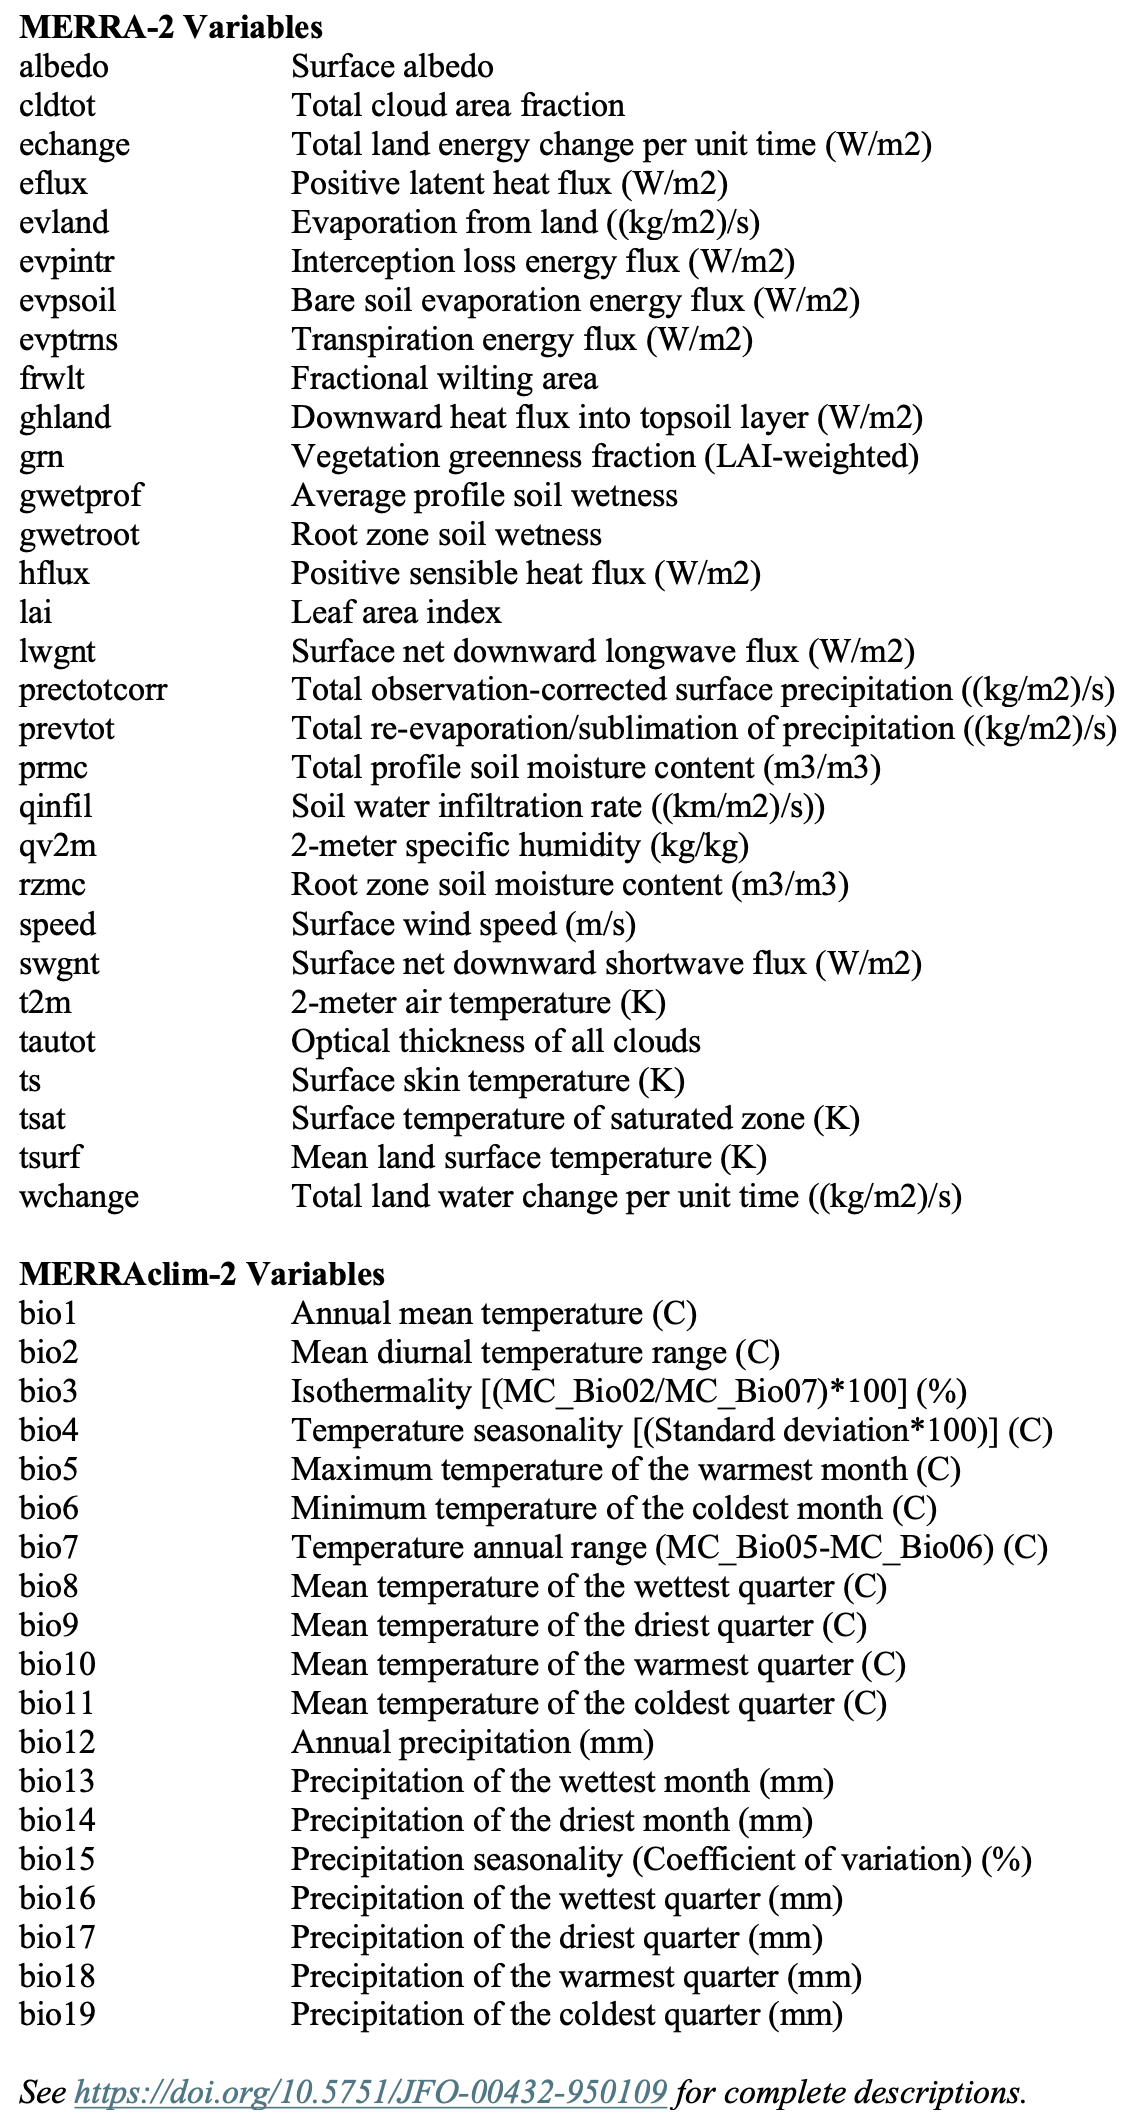



# APPENDIX C - Function reference

### rENM

| Function | Description | See |
|------------------------|------------------------|------------------------|
| `rENM()` | Execute the complete rENM pipeline for a target species | *The rENM Workflow* |

### rENM.core

| Function | Description | See |
|------------------------|------------------------|------------------------|
| `rENM_project_dir()` | Resolve the active project root | *Configuring the RStudio Environment* |
| `get_species_info()` | Retrieve metadata for a species by alpha code | *Performing an rENM Analysis* |
| `show_species()` | List species available in the project | *Performing an rENM Analysis* |
| `show_variables()` | List environmental variables available in the project | *Data Assembly* |

### rENM.data

All functions in this package are documented in *Data Assembly*.

| Function | Description |
|------------------------------------|------------------------------------|
| `find_occurrence_extent()` | Derive spatial extent from occurrence data |
| `find_range_extent()` | Derive spatial extent from a USGS GAP range polygon |
| `get_ebird_occurrences()` | Read and bin an eBird EBD file into five-year temporal bins |
| `get_merra_variables()` | Crop MERRA-2 predictor rasters to the species extent |
| `limit_record_count()` | Downsample bins to a maximum record count |
| `remove_duplicate_occurrences()` | Remove exact-coordinate duplicate records |
| `set_extent()` | Set spatial extent from explicit coordinates |
| `thin_occurrences()` | Sequential spatial thinning |
| `thin_occurrences2()` | Parallel spatial thinning with optional record cap |
| `tidy_occurrences()` | Move cleaned occurrence files from staging to main directory |

### rENM.model

All functions in this package are documented in *Time Series
Construction*.

| Function | Description |
|------------------------------------|------------------------------------|
| `create_ensemble_model()` | Fit an ensemble ENM for a single species and time bin |
| `create_range_map()` | Produce a binary presence-absence range map |
| `create_timeseries()` | Run ensemble models across all time bins in parallel |
| `plot_suitability()` | Plot a continuous climatic suitability raster |
| `rank_variable_importance()` | Parse and rank variable importance from an SDM model report |
| `reduce_covariance()` | Remove collinear predictors via adaptive VIF screening |
| `save_suitability_plot()` | Save a suitability plot to file |
| `screen_by_convergence1()` | Convergence-based variable screening via MaxEnt (requires Java) |
| `screen_by_convergence2()` | Convergence-based variable screening via maxnet (no Java dependency) |
| `stage_all_variables()` | Copy all predictor rasters into TimeSeries bins |
| `stage_occurrences()` | Copy occurrence files into TimeSeries bins |
| `stage_screened_variables()` | Copy screened predictors into TimeSeries bins |

### rENM.analysis

All functions in this package are documented in *Time Series Analysis*.

| Function | Description |
|------------------------------------|------------------------------------|
| `analyze_weighted_centroids()` | Fit Bayesian trends to centroid coordinates |
| `create_hot_spot_map()` | Map hotspot regions within states intersecting the GAP range |
| `create_state_trend_analysis()` | Per-state suitability trend map and statistics |
| `create_suitability_change_map()` | Suitability rate-of-change trend map |
| `find_bioclimatic_velocity()` | Estimate suitability displacement direction, distance, and velocity |
| `find_hot_spots()` | Identify cells with accelerating suitability declines |
| `find_range_change_percentages()` | Summarize trend proportions within the USGS GAP range |
| `find_suitability_change_trend()` | Compute trends in suitability rate of change |
| `find_suitability_trend()` | Compute per-cell Theil-Sen trends and Mann-Kendall statistics |
| `find_trend_percentages()` | Summarize trend proportions across the modeled extent |
| `find_weighted_centroid()` | Compute suitability-weighted spatial centroids (called internally by `analyze_weighted_centroids()`) |
| `gather_variable_contributions()` | Consolidate per-year variable importance files |
| `plot_suitability_change_trend()` | Plot suitability rate-of-change trend raster |
| `plot_trend()` | Plot a climatic suitability trend raster |
| `plot_trend_with_centroids()` | Plot suitability trend with centroid displacement overlay |
| `save_trend_plot()` | Save a suitability trend map to file |
| `save_trend_plot_with_centroids()` | Save a suitability trend map with centroid displacement vector |
| `summarize_variable_contributions()` | Frequentist and Bayesian trend analysis of variable contributions |

### rENM.ai

All functions in this package are documented in *GenAI Analysis*.

| Function | Description |
|------------------------------------|------------------------------------|
| `assemble_ai_package()` | Assemble AI-ready data bundle with analytical prompt |
| `render_ai_docx()` | Convert AI-generated DOCX report to PDF via LibreOffice |
| `submit_to_chatgpt()` | Submit data bundle to OpenAI and retrieve DOCX report |
| `submit_to_claude()` | Submit data bundle to Anthropic and retrieve DOCX report |
| `submit_to_claude_diag()` | Diagnose a failed `submit_to_claude()` response |

### rENM.reports

All functions in this package are documented in *Report Generation* and
*Assembling the Final Report*.

| Function | Description |
|------------------------------------|------------------------------------|
| `assemble_centroid_trends_page()` | Single-page PDF: centroid trend map and table |
| `assemble_final_report()` | Combine all pages into a single paginated PDF report |
| `assemble_range_timeseries_page()` | Single-page PDF: range time series contact sheet |
| `assemble_state_trends_page()` | Single-page PDF: state trend map, hotspot map, and table |
| `assemble_suitability_timeseries_page()` | Single-page PDF: suitability time series contact sheet |
| `assemble_suitability_trends_page()` | Single-page PDF: suitability trend and rate-of-change maps |
| `assemble_variable_trend_maps_page()` | Single-page PDF: variable trend map composites |
| `assemble_variable_trends_page()` | Single-page PDF: variable contributions plot and table |
| `create_centroid_trend_summary_table()` | Centroid shift and regression summary table |
| `create_suitability_trend_summary_table()` | State-level GAP range and hotspot summary table |
| `create_variable_trend_summary_table()` | Variable trend statistics summary table |
| `gather_range_maps()` | Assemble range map contact sheet |
| `gather_suitability_maps()` | Assemble suitability map contact sheet |
| `gather_suitability_trend_stats()` | Merge state-level suitability and hotspot statistics |
| `gather_top_variable_trend_maps()` | Assemble variable trend map composites |